# Notebook 2 — Create the Labels

**Goal:** build the late/on-time label from
`order_delivered_customer_date` vs `order_estimated_delivery_date`,
sanity-check it, and look at the class balance.

In [1]:
import pandas as pd
import numpy as np

ARTIFACTS_DIR = "artifacts"
ml_table = pd.read_parquet(f"{ARTIFACTS_DIR}/01_ml_table.parquet")

date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in date_cols:
    ml_table[c] = pd.to_datetime(ml_table[c], errors="coerce")

ml_table[date_cols].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## Only orders that were actually delivered can be labeled
Orders that are cancelled / still in transit have no
`order_delivered_customer_date` — they cannot get a late/on-time label and
must be excluded from the modeling table (they are a different problem).

In [2]:
print(ml_table['order_status'].value_counts())
print()
print("Missing delivered_customer_date:", ml_table['order_delivered_customer_date'].isna().sum())
print("Missing estimated_delivery_date:", ml_table['order_estimated_delivery_date'].isna().sum())

labeled = ml_table[ml_table['order_delivered_customer_date'].notna() &
                    ml_table['order_estimated_delivery_date'].notna()].copy()
print("Rows kept for labeling:", len(labeled), "/", len(ml_table))

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing delivered_customer_date: 2965
Missing estimated_delivery_date: 0
Rows kept for labeling: 96476 / 99441


In [3]:
# ---- Build the label ----
labeled['delivery_delay_days'] = (
    labeled['order_delivered_customer_date'] - labeled['order_estimated_delivery_date']
).dt.total_seconds() / 86400

labeled['is_late'] = (labeled['delivery_delay_days'] > 0).astype(int)
labeled[['order_id', 'order_delivered_customer_date',
         'order_estimated_delivery_date', 'delivery_delay_days', 'is_late']].head(10)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-9.238171,0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,-5.543113,0
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,-11.461215,0
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,-31.410995,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,-6.281597,0
10,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-29 11:18:31,2017-06-07,-8.528808,0


## Check the label is correct on a few real orders
Manually eyeball a few late and a few on-time rows to make sure the logic
matches what you'd expect before trusting it.

In [4]:
print("Sample LATE orders:")
display(labeled[labeled['is_late']==1][
    ['order_id','order_delivered_customer_date','order_estimated_delivery_date','delivery_delay_days']
].sample(5, random_state=42))

print("Sample ON-TIME orders:")
display(labeled[labeled['is_late']==0][
    ['order_id','order_delivered_customer_date','order_estimated_delivery_date','delivery_delay_days']
].sample(5, random_state=42))

Sample LATE orders:


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
14176,91c4fb2a013280c780ea608101fcac7c,2017-11-18 14:38:35,2017-11-17,1.610127
80150,51d52f115820f57bd947308b77f392db,2018-01-09 17:19:36,2018-01-05,4.721944
33355,18b5dc19d0cf40a8d307902c30296340,2018-03-27 22:25:49,2018-03-23,4.934595
21381,98ff4145b11d1c215563ee9ca819f5da,2018-03-19 22:57:44,2018-03-19,0.956759
71266,b04215f2cbc4e1fdd167427e657c7d16,2017-03-20 09:37:32,2017-03-09,11.401065


Sample ON-TIME orders:


,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
71364,ec6dc3377849564c30896b7543229e2d,2017-11-13 20:33:19,2017-11-21,-7.143530
59221,31725408e39733c6fbccf9559d25f0e4,2017-11-09 19:40:20,2017-11-22,-12.180324
4274,fa145f6e474f19a183553a249dc5a73b,2017-10-27 21:28:01,2017-11-09,-12.105544
87177,dd5ebf00c3d8b88a41ec9c8450ec59db,2017-04-18 12:27:13,2017-05-04,-15.481100
10599,635c894d068ac37e6e03dc54eccb6189,2017-05-16 14:49:55,2017-05-18,-1.382002


## Class distribution — is this an imbalance problem?

is_late
0    88649
1     7827
Name: count, dtype: int64
is_late
0    91.89
1     8.11
Name: proportion, dtype: float64


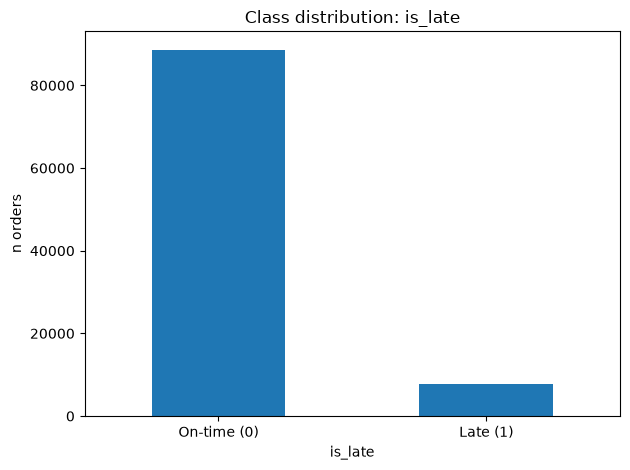

In [5]:
counts = labeled['is_late'].value_counts()
pct = labeled['is_late'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

import matplotlib.pyplot as plt
counts.sort_index().plot(kind='bar')
plt.xticks([0,1], ['On-time (0)', 'Late (1)'], rotation=0)
plt.title('Class distribution: is_late')
plt.ylabel('n orders')
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/02_class_distribution.png", dpi=120)
plt.show()

**Decide if you have a class imbalance problem, and how big it is.**
Olist is a real-world delivery dataset — expect on-time orders to dominate
(commonly ~90/10 or ~93/7). Write your actual numbers down here once you run
the cell above, e.g.:

> On-time: XX.X% — Late: XX.X% → this is a [mild / moderate / severe] imbalance.
> This will drive the metric choice in Notebook 6 (do not use plain accuracy).

## Artifact: the labeled table

In [6]:
labeled.to_parquet(f"{ARTIFACTS_DIR}/02_labeled_table.parquet", index=False)
print("Saved:", f"{ARTIFACTS_DIR}/02_labeled_table.parquet", "| shape:", labeled.shape)

Saved: artifacts/02_labeled_table.parquet | shape: (96476, 25)
